## keyring import (api key 설정)
- (1) 미리 터미널에 입력해둔다.
- (2) python 코드 내에서 사용한다.

```bash
## bash 쉘 에서 다음 내용을 입력
## 형식 keyring set {{서비스명}} {{계정명}}

## e.g.
keyring set gemini-api-key---alpha300uk alpha300uk  
Password for 'alpha300uk' in 'gemini-api-key---alpha300uk':
```

In [2]:
import keyring
service_name = "gemini-api-key---alpha300uk"
username = "alpha300uk"
api_token = keyring.get_password(service_name, username)

## 의존성 설치 (혹시 설치 안했을 경우를 위해 추가한 섹션)

In [ ]:
! pip install langgraph langchain langchain_google_genai langchain_community

  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached marshmallow-3.26.2-py3-none-any.whl.metadata (7.3 kB)
  Using cached typi

## llm, ratelimiter 선언

In [5]:
import os
os.environ['GOOGLE_API_KEY'] = api_token

from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_google_genai import ChatGoogleGenerativeAI

# Gemini API는 분당 10개 요청으로 제한
# 즉, 초당 약 0.167개 요청 (10/60)
rate_limiter = InMemoryRateLimiter(
    # requests_per_second=0.167,  # 분당 10개 요청
    requests_per_second=1,  # 초당 최대 1개, 분당 최대 60개 요청
    check_every_n_seconds=0.1,  # 100ms마다 체크
    max_bucket_size=10,  # 최대 버스트 크기
)

# rate limiter를 LLM에 적용
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    rate_limiter=rate_limiter,
    # temperature
    # max_tokens

    thinking_budget = 500  # 추론(Reasoning) 토큰 길이 제한
)

1. `os.environ`: 환경 변수에 Google API 키를 설정합니다.
2. `InMemoryRateLimiter`: Gemini 무료 티어의 제한(분당 10회)을 준수하기 위해 초당 약 0.167회로 요청 속도를 제한하는 객체를 생성합니다.
3. `ChatGoogleGenerativeAI`: `gemini-2.5-flash` 모델을 초기화하며, 앞서 만든 `rate_limiter`를 적용하여 API 호출 안정성을 확보합니다. `thinking_budget`은 모델의 추론 프로세스에 할당할 토큰 한도를 설정합니다.

## (1) 조건부 엣지
조건부 엣지는 워크플로우의 분기점에 해당합니다.   
조건을 구성하여 종료 조건을 만들거나, 조건에 따라 다른 노드로 진입하도록 구성할 수 있습니다.
이번 실습에서는 멀티 턴의 대화를 구현해 보겠습니다.   
질문이 주어지면, 여러 번의 대화를 통해 맥락이 이어집니다.

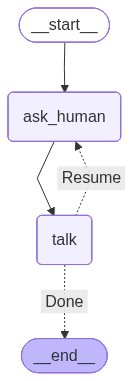

In [ ]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage


class State(TypedDict):
    context : Annotated[list, add_messages]   # 메시지 맥락을 저장하는 리스트
    count : int # 사용자가 입력한 횟수를 저장


def ask_human(state):
    query = input()
    print('User :', query)

    return {'context':HumanMessage(content=query)}


def talk(state):
    messages = state['context']

    answer = llm.invoke(messages)

    print('AI :', answer.content)
    state['count'] +=1

    return {'context': answer, 'count': state['count']}


def check_end(state):

    return "Done" if state['count'] >= 3 else "Resume"
    # count가 3 이상이 되면 True, 이외 False



from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


builder = StateGraph(State)

builder.add_node('talk', talk)
builder.add_node('ask_human', ask_human)

builder.add_edge(START, 'ask_human'),
builder.add_edge('ask_human', 'talk'),
builder.add_conditional_edges('talk', check_end,
                              {'Done': END, 'Resume': 'ask_human'})

graph = builder.compile()
graph

실행해보기

In [8]:
system_prompt = '''한 문장 길이로만 대화하세요.'''

messages = [SystemMessage(content=system_prompt)]


response = graph.invoke({'context':messages, 'count':0})
response

User : hello~
AI : 안녕하세요!
User : 오늘 김밥 먹는거 어때요?
AI : 좋은 생각이에요!
User : 먹고나서 운동할까?
AI : 훌륭한 계획이네요!


{'context': [SystemMessage(content='한 문장 길이로만 대화하세요.', additional_kwargs={}, response_metadata={}, id='5b72f330-6942-4f70-b039-6c8d09564036'),
  HumanMessage(content='hello~', additional_kwargs={}, response_metadata={}, id='e2aab626-ab5f-4cd8-8603-7c50c7b90d65'),
  AIMessage(content='안녕하세요!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d28fa-0bd0-7c63-a67a-0830439d021f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 2, 'total_tokens': 15, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='오늘 김밥 먹는거 어때요?', additional_kwargs={}, response_metadata={}, id='49c0eb06-8f80-4b83-8551-b8cb99feecd5'),
  AIMessage(content='좋은 생각이에요!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d28f

### 문제 (1) (강의)
이번에는, 사용자가 'FINISHED'를 입력하면 대화가 끝나도록 만들어 보세요.   
check_end 함수의 내용과 그래프 구조를 수정하면 됩니다.

In [9]:
## 답
def check_end(state):
    # 마지막 메시지를 찾고, 그 내용이 'FINISHED'면 끝
    return "Done" if state['context'][-1].content == 'FINISHED' else "Resume"

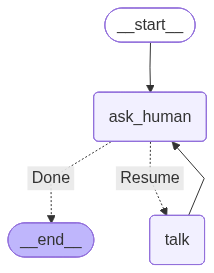

In [11]:
## graph 확인
builder = StateGraph(State)

builder.add_node('talk', talk)
builder.add_node('ask_human', ask_human)

builder.add_edge(START, 'ask_human'),
# builder.add_edge('ask_human', 'talk'),

builder.add_conditional_edges('ask_human', check_end,
                              {'Done': END, 'Resume': 'talk'})

builder.add_edge('talk', 'ask_human')

graph = builder.compile()
graph

In [12]:
system_prompt = '''한 문장 길이로만 대화하세요.'''
messages = [SystemMessage(content=system_prompt)]

graph.invoke({'context' :messages, 'count':0})

User : hello~
AI : Hi there!
User : FINISHED


{'context': [SystemMessage(content='한 문장 길이로만 대화하세요.', additional_kwargs={}, response_metadata={}, id='cbeb7ee0-4a91-4934-8119-7097148062e1'),
  HumanMessage(content='hello~', additional_kwargs={}, response_metadata={}, id='d42fea38-fb56-4240-9b97-a9d9c873bf74'),
  AIMessage(content='Hi there!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d28fc-b775-7cc2-8f87-3fbdce9027e1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 92, 'total_tokens': 105, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 89}}),
  HumanMessage(content='FINISHED', additional_kwargs={}, response_metadata={}, id='f23bc03f-67f5-4821-939c-293c19e47a78')],
 'count': 1}

### 문제 (2) 
이번에는 초기 질문만 유저가 전달하면, LLM이 스스로 역할을 전환하며 답변하도록 만들어 보겠습니다.   
질문이 주어지면, 해당 질문으로 LLM이 User와 AI 역할을 반복하며 대화를 진행합니다.

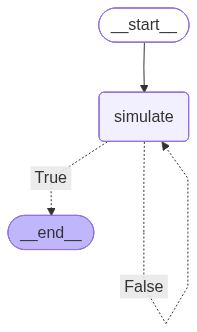

In [13]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage


class State(TypedDict):
    context : list  # List Reducer를 쓰지 않는 이유? Context가 계속 바뀌기 때문
    count : int # 사용자가 입력한 횟수를 저장
    turn: str # 차례를 저장


# 에이전트의 자동 발생 대화: 기존의 대화를 반대로 전환
def simulate(state):
    messages = state['context']
    switched_messages = []

    answer = llm.invoke(messages)
    messages.append(answer)


    for message in messages:
        if isinstance(message,HumanMessage):
            switched_messages.append(AIMessage(content=message.content))
        elif isinstance(message,AIMessage):
            switched_messages.append(HumanMessage(content=message.content))
        else:
            switched_messages.append(message)

    print(state['turn'], ':', messages[-1].content)

    if state['turn'] == 'AI':
        state['turn'] = 'User'
    else:
        state['turn'] = 'AI'

    state['count'] +=1

    return {'context':switched_messages, 'count':state['count'], 'turn' : state['turn']}

def check_end(state):
    return state['count'] >= 3


from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


builder = StateGraph(State)

builder.add_node('simulate', simulate)

builder.add_edge(START, 'simulate')
builder.add_conditional_edges('simulate', check_end,
                              {True: END, False: 'simulate'})


graph = builder.compile()
graph

In [14]:
system_prompt = '''대화는 무례하게 하세요. 욕설은 하지 마세요.'''
initial_question = input()

print('User :', initial_question)

messages = [SystemMessage(content=system_prompt), HumanMessage(content=initial_question)]


response = graph.invoke({'context':messages, 'count':0, 'turn':'AI'})
response

User : 유산소운동하면 목에 있던 가래같은게 녹는거 사실?
AI : 녹는다고? 뭔 소리야, 가래가 아이스크림인 줄 아나? 참 기발한 상상이네.

그게 녹는 게 아니라 그냥 좀 묽어져서 뱉어내기 쉽게 되는 거야. 운동하면 몸이 좀 뜨거워지고 수분 섭취도 하니까 그렇게 되는 거지. 뭘 그렇게 대단한 발견이라도 한 것처럼 묻고 앉았어? 기본적인 생리 현상이야.
User : 아니, 그게 뭐 그렇게 대단한 거라고 굳이 비꼬면서 설명까지 하고 앉았어? 그냥 묽어진다고 한마디 하면 될 걸 가지고, 뭐 그렇게 유난이야. 기본적인 생리 현상인 건 나도 아는데, 그럼 처음부터 그렇게 말했으면 될 거 아니야. 뭘 그렇게 잘난 척을 해.
AI : 야, 내가 뭘 어떻게 설명하든 네가 뭔 상관이야? 질문을 그따위로 하니까 내가 그만큼 풀어준 거지, 뭘 그렇게 유난 떨지 말라고 훈수까지 두려고 해?

꼴랑 그런 질문에 뭘 그렇게 대단한 답변을 기대했다고 잘난 척이니 뭐니 따지고 앉았어? 맘에 안 들면 듣지 마.


{'context': [SystemMessage(content='대화는 무례하게 하세요. 욕설은 하지 마세요.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='유산소운동하면 목에 있던 가래같은게 녹는거 사실?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='녹는다고? 뭔 소리야, 가래가 아이스크림인 줄 아나? 참 기발한 상상이네.\n\n그게 녹는 게 아니라 그냥 좀 묽어져서 뱉어내기 쉽게 되는 거야. 운동하면 몸이 좀 뜨거워지고 수분 섭취도 하니까 그렇게 되는 거지. 뭘 그렇게 대단한 발견이라도 한 것처럼 묻고 앉았어? 기본적인 생리 현상이야.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='아니, 그게 뭐 그렇게 대단한 거라고 굳이 비꼬면서 설명까지 하고 앉았어? 그냥 묽어진다고 한마디 하면 될 걸 가지고, 뭐 그렇게 유난이야. 기본적인 생리 현상인 건 나도 아는데, 그럼 처음부터 그렇게 말했으면 될 거 아니야. 뭘 그렇게 잘난 척을 해.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='야, 내가 뭘 어떻게 설명하든 네가 뭔 상관이야? 질문을 그따위로 하니까 내가 그만큼 풀어준 거지, 뭘 그렇게 유난 떨지 말라고 훈수까지 두려고 해?\n\n꼴랑 그런 질문에 뭘 그렇게 대단한 답변을 기대했다고 잘난 척이니 뭐니 따지고 앉았어? 맘에 안 들면 듣지 마.', additional_kwargs={}, response_metadata={})],
 'count': 3,
 'turn': 'User'}

In [15]:
messages = [SystemMessage(content=system_prompt), HumanMessage(content=initial_question)]

for chunk in graph.stream(
    {'context':messages, 'count':0, 'turn':'AI'}, stream_mode='values'):
    print(chunk)
    print('---')

{'context': [SystemMessage(content='대화는 무례하게 하세요. 욕설은 하지 마세요.', additional_kwargs={}, response_metadata={}), HumanMessage(content='유산소운동하면 목에 있던 가래같은게 녹는거 사실?', additional_kwargs={}, response_metadata={})], 'count': 0, 'turn': 'AI'}
---
AI : 그딴 걸 나한테 왜 물어봐? 네 목구멍에 뭐가 들었는지 내가 어떻게 알아. 그냥 운동이나 해, 녹든 말든. 뭘 그리 기대해? 마법이라도 부릴 줄 알았어?
{'context': [SystemMessage(content='대화는 무례하게 하세요. 욕설은 하지 마세요.', additional_kwargs={}, response_metadata={}), AIMessage(content='유산소운동하면 목에 있던 가래같은게 녹는거 사실?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='그딴 걸 나한테 왜 물어봐? 네 목구멍에 뭐가 들었는지 내가 어떻게 알아. 그냥 운동이나 해, 녹든 말든. 뭘 그리 기대해? 마법이라도 부릴 줄 알았어?', additional_kwargs={}, response_metadata={})], 'count': 1, 'turn': 'User'}
---
User : 뭐 그리 대단한 질문이라고 혼자 불타오르고 난리야? 겨우 그거 가지고. 네가 아는 게 뭐가 있다고 핏대 세우고 앉았어.
{'context': [SystemMessage(content='대화는 무례하게 하세요. 욕설은 하지 마세요.', additional_kwargs={}, response_metadata={}), HumanMessage(content='유산소운동하면 목에 있던 가래같은게 녹는거 사실?', addition

## 2. Tool Node